<div style="background-color: #fdfbf7; padding: 25px; border-radius: 8px; border: 1px solid #e3dec3; font-family: 'Times New Roman', Times, serif; color: #111111; line-height: 1.6;">

<h1 style="font-family: 'Times New Roman', Times, serif; color: #1a252c; margin-top: 0; font-size: 24px;">
Air Quality Across India & AQI Analytics Dashboard
</h1>

<p style="font-size: 16px; margin-bottom: 20px;">
<strong> An analytical data science pipeline designed to uncover multi-year urban pollution trends, identify primary toxic contributors, and evaluate environmental health risks across India.</strong>

<div style="background-color: #fdfbf7; padding: 25px; border-radius: 8px; border: 1px solid #e3dec3; font-family: 'Times New Roman', Times, serif; color: #111111; line-height: 1.6;">

<h2 style="font-family: 'Times New Roman', Times, serif; color: #1a252c; margin-top: 0;">
Project Overview: Air Quality Across India & AQI Analytics Dashboard
</h2>

<p style="font-size: 16px; margin-bottom: 15px;">
Air pollution is one of the most critical environmental and public health challenges in urban India. This project presents a comprehensive data analytics pipeline built using Python, Pandas, and visualization libraries to ingest, clean, explore, and visualize multi-year urban air quality records spanning multiple metropolitan regions.
</p>

<h3 style="font-family: 'Times New Roman', Times, serif; color: #2c3e50; margin-top: 20px;">
Project Objective
</h3>
<p style="font-size: 16px; margin-bottom: 15px;">
To systematically clean, analyze, and visualize multi-year urban air quality data across India in order to uncover hidden pollution trends, identify primary toxic contributors such as particulate matter and gaseous pollutants, evaluate seasonal environmental variations, and assess overall public health risks through an analytical dashboard framework.
</p>

<h3 style="font-family: 'Times New Roman', Times, serif; color: #2c3e50; margin-top: 20px;">
Data Introduction & Source
</h3>
<p style="font-size: 16px; margin-bottom: 15px;">
The project utilizes the Air Quality Data in India (2015–2020) dataset sourced from Kaggle, originating from Central Pollution Control Board monitoring stations. For macro-level urban analytics and dashboard structure, we utilize the primary city_day.csv dataset, which provides daily aggregated pollution parameters and calculated Air Quality Index values across major Indian cities.
</p>

<h3 style="font-family: 'Times New Roman', Times, serif; color: #2c3e50; margin-top: 20px;">
Column Description & Schema
</h3>
<ul style="font-size: 16px; margin-bottom: 0;">
<li><strong>City:</strong> Name of the urban center or metropolitan city being monitored.</li>
<li><strong>Date:</strong> The timestamp of the recorded daily observation formatted to DateTime.</li>
<li><strong>PM2.5 / PM10:</strong> Fine and coarse particulate matter concentrations measured in micrograms per cubic meter.</li>
<li><strong>NO, NO2, NOx:</strong> Nitrogen oxides representing vehicular and industrial emissions.</li>
<li><strong>NH3, SO2, O3:</strong> Ammonia, sulfur dioxide, and ambient ozone concentrations.</li>
<li><strong>CO:</strong> Carbon monoxide concentration levels.</li>
<li><strong>Benzene, Toluene, Xylene:</strong> Volatile organic compounds tracked in the atmosphere.</li>
<li><strong>AQI:</strong> The calculated numerical Air Quality Index representing overall air pollution severity.</li>
<li><strong>AQI_Bucket:</strong> Qualitative health classification category such as Good, Moderate, Poor, or Severe.</li>
</ul>

</div>

### Task 1: Data Loading, Inspection, Cleaning, and Pre-processing
1. Importing multiple raw CSV sources and inspecting their structures.
2. Merging relational data.
3. Handling missing values and duplicate records.
4. Correcting data types (converting timestamps).
5. Engineering derived features (temporal breakdowns and AQI categorization buckets).

### 1. Data Loading and Initial Overview
We begin by importing necessary libraries (`pandas` and `numpy`) and loading our raw datasets. We will inspect the shape, column data types, and structural statistics to understand our raw inputs.

In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load the primary CSV files
# Update the file paths if they are located inside a subfolder (e.g., 'data/city_day.csv')
city_day_df = pd.read_csv('city_day.csv')
stations_df = pd.read_csv('stations.csv')

In [10]:
print("--- City Day Dataset Overview ---")
print(f"Number of Rows and Columns: {city_day_df.shape}")
display(city_day_df.head(5))

print("\n--- Stations Metadata Dataset Overview ---")
print(f"Number of Rows and Columns: {stations_df.shape}")
display(stations_df.head(5))

--- City Day Dataset Overview ---
Number of Rows and Columns: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



--- Stations Metadata Dataset Overview ---
Number of Rows and Columns: (230, 5)


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


## Data Information and Description...

In [2]:
print("=== City Day Dataset Info ===")
city_day_df.info()

print("\n=== Summary Statistics (City Day) ===")
display(city_day_df.describe())

=== City Day Dataset Info ===


NameError: name 'city_day_df' is not defined

### 2. Merging Relational Datasets
The dataset provides separate files for city-level metrics and station metadata. To enrich our city-level or station-level analysis with geographical details (such as station coordinates or specific zones), we can merge them using common keys like `City` or `StationId`. Here, we inspect how `stations.csv` links to our records.

In [14]:
# Check unique cities in both datasets to verify matching keys
print("Unique cities in city_day:", city_day_df['City'].nunique())
print("Unique cities in stations:", stations_df['City'].nunique() if 'City' in stations_df.columns else "City column format check needed")

Unique cities in city_day: 26
Unique cities in stations: 127


In [ ]:
# If working with station-level data (e.g., station_day.csv), you would merge like this:
# merged_station_df = pd.read_csv('station_day.csv').merge(stations_df, on='StationId', how='left')

# For our primary macro dashboard, city_day_df is self-contained by City and Date.
# We will clean city_day_df directly as our core analytics dataframe.

In [15]:
df = city_day_df.copy()
print("Base Working DataFrame Shape:", df.shape)

Base Working DataFrame Shape: (29531, 16)


### 3. Data Pre-cleaning: Duplicates & Missing Values
Raw environmental sensor logs often contain duplicated rows or missing pollutant values due to sensor downtime or maintenance. We will quantify these issues before applying imputation or removal strategies.

In [16]:
# 1. Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# If duplicates exist, drop them:
if duplicates_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

# 2. Check missing values percentage per column
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("\nMissing Values Breakdown:")
display(missing_data[missing_data['Missing Count'] > 0])

Number of duplicate rows: 0

Missing Values Breakdown:


,Missing Count,Missing Percentage (%)
PM2.5,4598,15.570079
PM10,11140,37.723071
NO,3582,12.129626
NO2,3585,12.139785
NOx,4185,14.171549
NH3,10328,34.973418
CO,2059,6.972334
SO2,3854,13.050692
O3,4022,13.619586
Benzene,5623,19.041008


### 4. Handling Missing Values & Correcting Data Types
* **Date Column:** The `Date` column must be converted from `object` (string) to `datetime64` format to enable time-series plotting and feature engineering.
* **Pollutant Columns:** Missing values in environmental datasets cannot simply be dropped blindly, as it would destroy the time-series continuity. We apply **forward-fill (`ffill`)** grouped by city to propagate the last known valid reading for short gaps, or leave structural gaps where continuous tracking wasn't active.

In [18]:
# Correct Data Type for Date
df['Date'] = pd.to_datetime(df['Date'])
print("Converted 'Date' column to datatype:", df['Date'].dtype)

Converted 'Date' column to datatype: datetime64[us]


In [20]:
# Handle Missing Values in Pollutants and AQI
# Grouping by City ensures we only fill values using data from the same city
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for col in pollutant_cols:
    if col in df.columns:
        # Forward fill within each city group to handle minor intermittent missing sensors
        df[col] = df.groupby('City')[col].transform('ffill')

# For remaining rows where an entire city series starts with NaN, fill with the median of that specific city or overall median
for col in pollutant_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df.groupby('City')[col].transform('median'))
        # Fallback to global median if city median is also NaN
        df[col] = df[col].fillna(df[col].median())

In [21]:
print("Remaining missing values after cleaning:", df.isnull().sum().sum())

Remaining missing values after cleaning: 4681


In [23]:
#CHECKING....

In [30]:
display(missing_data[missing_data['Missing Count'] > 0])

,Missing Count,Missing Percentage (%)
AQI_Bucket,4681,15.851139


In [42]:
# 1. Defining the official CPCB classification function for AQI Buckets
# Categorizing AQI into Health Buckets based on CPCB (Central Pollution Control Board) standards
def get_aqi_bucket(aqi):
    if pd.isna(aqi):
        return 'Unknown'
    elif aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

In [25]:
# 2. Fill missing values in 'AQI_Bucket' by applying the function to the 'AQI' column
df['AQI_Bucket'] = df['AQI_Bucket'].fillna(df['AQI'].apply(get_aqi_bucket))

In [27]:
# 3. Checking if any rows still have missing values, label them 'Unknown'
df['AQI_Bucket'] = df['AQI_Bucket'].fillna('Unknown')

In [29]:
# Verification output
print("Remaining missing values in AQI_Bucket:", df['AQI_Bucket'].isnull().sum())
print("\nDistribution of AQI Buckets:")
display(df['AQI_Bucket'].value_counts())

Remaining missing values in AQI_Bucket: 0

Distribution of AQI Buckets:


AQI_Bucket
Satisfactory    10353
Moderate         9841
Poor             3289
Very Poor        3046
Good             1590
Severe           1412
Name: count, dtype: int64

In [39]:
missing_bucket_count = df['AQI_Bucket'].isnull().sum()
display(missing_bucket_count)

np.int64(0)

### 5. Creating Derived Features
To assist with advanced exploratory data analysis (EDA) and dashboard filtering, we will extract temporal components (`Year`, `Month`, `DayOfWeek`, `Season`) and categorize continuous AQI values into standard qualitative health buckets (e.g., *Good*, *Moderate*, *Poor*, *Severe*).

In [40]:
# Extract Temporal Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%B')
df['DayOfWeek'] = df['Date'].dt.day_name()

In [41]:
# Define a function to map months to Indian Seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

In [44]:
# Categorize AQI into Health Buckets based on CPCB (Central Pollution Control Board) standards
def categorize_aqi(aqi):
    if pd.isna(aqi):
        return 'Unknown'
    elif aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Bucket_Calculated'] = df['AQI'].apply(categorize_aqi)

# Preview engineered features
print("Derived features sample preview:")
display(df[['City', 'Date', 'AQI', 'AQI_Bucket_Calculated', 'Season', 'Year']].head())

Derived features sample preview:


,City,Date,AQI,AQI_Bucket_Calculated,Season,Year
0,Ahmedabad,2015-01-01,361.0,Very Poor,Winter,2015
1,Ahmedabad,2015-01-02,361.0,Very Poor,Winter,2015
2,Ahmedabad,2015-01-03,361.0,Very Poor,Winter,2015
3,Ahmedabad,2015-01-04,361.0,Very Poor,Winter,2015
4,Ahmedabad,2015-01-05,361.0,Very Poor,Winter,2015


### 6. Exporting Processed Data
Now that data cleaning, type casting, missing value treatment, and feature engineering are complete, we export the refined dataset to a new CSV file. This file will be utilized directly for futher analysis.

In [46]:
# Save cleaned dataframe
output_filename = 'cleaned_city_day_air_quality.csv'
df.to_csv(output_filename, index=False)

print(f"Data preprocessing complete! Cleaned dataset successfully saved as '{output_filename}'.")
print(f"Final dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")

Data preprocessing complete! Cleaned dataset successfully saved as 'cleaned_city_day_air_quality.csv'.
Final dataset dimensions: 29531 rows, 22 columns.


### 7. Outlier Checking: Descriptive Statistics Method
By utilizing pandas `.describe()`, we can compare the 75th percentile against the maximum value. 
    A massive jump indicates extreme outlier values in the dataset.

In [47]:
# Check stats for PM2.5 and AQI
print(df[['PM2.5', 'AQI']].describe())

              PM2.5           AQI
count  29531.000000  29531.000000
mean      66.240474    165.565203
std       64.220537    137.700816
min        0.040000     13.000000
25%       27.030000     84.000000
50%       46.850000    116.000000
75%       80.650000    210.000000
max      949.990000   2049.000000


## Task 2: Exploratory Data Analysis & Visualizations 

This section covers comprehensive data exploration and visual storytelling to uncover urban pollution patterns across India. The analysis is structured into the following core components:

*   **Univariate Statistical Summaries:** 
    *   Evaluating central tendencies (mean, median), dispersion, and frequency distributions.
    *   Analyzing baseline characteristics of individual pollutants (`PM2.5`, `PM10`, `NO2`, etc.) and the Air Quality Index (`AQI`).

*   **Bivariate & Multivariate Groupby Analysis:** 
    *   Applying advanced aggregation methods, pivot tables, and grouping (`groupby`) functions.
    *   Comparing air quality trends across different cities, multi-year timelines, and changing seasonal cycles.

*   **Correlation & Matrix Analysis:** 
    *   Executing multivariate correlation computations between various gaseous and particulate pollutants.
    *   Identifying the primary toxic contributors driving high AQI levels.

*   **Comprehensive Visual Storytelling (10+ Plots):** 
    *   Generating publication-grade visualizations using `Matplotlib` and `Seaborn`.
    *   Covering correlation heatmaps, seasonal box plots, bar charts, multi-line trends, and distribution histograms.

### A. Exploratory Data Analysis (EDA)
In this section, we conduct descriptive and exploratory analysis on our cleaned dataset (`cleaned_city_day_air_quality.csv`). We will examine statistical summaries, aggregate data using `groupby` and pivot tables, and analyze correlations between key pollutants and AQI to uncover underlying pollution trends and toxic contributors.

### 1. Statistical Summaries & Univariate Analysis
Evaluating central tendencies (mean, median), dispersion, and frequency distributions.
Analyzing baseline characteristics of individual pollutants (`PM2.5`, `PM10`, `NO2`, etc.) and the Air Quality Index (`AQI`).

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn_plt
import warnings
warnings.filterwarnings('ignore')

# Set visual style
seaborn_plt.set_theme(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv('cleaned_city_day_air_quality.csv')
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

print("=== Statistical Summary of Numerical Features ===")
display(df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']].describe())

=== Statistical Summary of Numerical Features ===


,PM2.5,PM10,NO2,CO,SO2,O3,AQI
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,66.240474,111.157990,27.133315,2.292774,15.937238,33.842865,165.565203
std,64.220537,77.807423,23.577758,6.824255,20.507290,21.654760,137.700816
min,0.040000,0.010000,0.010000,0.000000,0.010000,0.010000,13.000000
25%,27.030000,60.880000,11.630000,0.500000,5.760000,18.870000,84.000000
50%,46.850000,97.150000,20.065000,0.910000,9.680000,29.550000,116.000000
75%,80.650000,127.105000,35.030000,1.490000,15.910000,44.235000,210.000000
max,949.990000,1000.000000,362.210000,175.810000,193.860000,257.730000,2049.000000


In [51]:
print("\n=== AQI Distribution Across Health Buckets ===")
bucket_counts = df['AQI_Bucket_Calculated'].value_counts()
bucket_percentage = df['AQI_Bucket_Calculated'].value_counts(normalize=True) * 100
bucket_summary = pd.DataFrame({'Count': bucket_counts, 'Percentage (%)': bucket_percentage.round(2)})
display(bucket_summary)


=== AQI Distribution Across Health Buckets ===


,Count,Percentage (%)
AQI_Bucket_Calculated,,
Satisfactory,10353,35.06
Moderate,9841,33.32
Poor,3289,11.14
Very Poor,3046,10.31
Good,1590,5.38
Severe,1412,4.78


### 2. Bivariate & Multivariate Analysis (Groupby & Pivot Tables)
Applying advanced aggregation methods, pivot tables, and grouping (`groupby`) functions.
Comparing air quality trends across different cities, multi-year timelines, and changing seasonal cycles.

In [54]:
# 1. Groupby Analysis: Average AQI by City (Top 10 most polluted cities on average)
city_aqi = df.groupby('City')['AQI'].mean().reset_index()
top_polluted_cities = city_aqi.sort_values(by='AQI', ascending=False).head(10)

print("--- Top 10 Cities with Highest Average AQI ---")
display(top_polluted_cities)

--- Top 10 Cities with Highest Average AQI ---


,City,AQI
0,Ahmedabad,422.602290
10,Delhi,258.632653
21,Patna,241.945640
12,Gurugram,230.544967
19,Lucknow,215.735689
23,Talcher,162.528649
6,Brajrajnagar,145.682303
16,Jorapokhar,143.431993
13,Guwahati,139.418327
18,Kolkata,135.312039


In [55]:
# 2. Groupby Analysis: Average Pollution Levels by Season
seasonal_pollution = df.groupby('Season')[['PM2.5', 'PM10', 'NO2', 'CO', 'AQI']].mean()
print("\n--- Average Pollution Metrics by Season ---")
display(seasonal_pollution)


--- Average Pollution Metrics by Season ---


,PM2.5,PM10,NO2,CO,AQI
Season,,,,,
Monsoon,41.520069,86.054430,20.990001,2.039726,121.278354
Post-Monsoon,86.657205,127.443780,33.879307,2.793786,205.018145
Summer,57.350213,105.285930,24.215351,1.852470,150.997824
Winter,94.958126,139.480263,34.054552,2.799891,213.775806


In [56]:
# 3. Pivot Table: Average AQI by Year and Season
aqi_pivot = pd.pivot_table(
    df, 
    values='AQI', 
    index='Year', 
    columns='Season', 
    aggfunc='mean'
).round(2)

print("\n--- Pivot Table: Multi-Year Average AQI by Season ---")
display(aqi_pivot)


--- Pivot Table: Multi-Year Average AQI by Season ---


Season,Monsoon,Post-Monsoon,Summer,Winter
Year,,,,
2015,162.37,237.03,184.65,210.58
2016,139.60,226.27,202.83,247.21
2017,136.88,212.79,188.59,222.21
2018,118.04,221.78,162.43,240.46
2019,103.26,166.66,157.86,212.07
2020,76.80,NaN,94.46,162.99


### 3. Correlation Analysis (Multivariate)
Executing multivariate correlation computations between various gaseous and particulate pollutants.
Identifying the primary toxic contributors driving high AQI levels.


In [59]:
# Calculate correlation matrix for pollutants and AQI
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
correlation_matrix = df[pollutant_cols].corr()

print("--- Correlation Matrix Summary with AQI ---")
display(correlation_matrix[['AQI']].sort_values(by='AQI', ascending=False))

--- Correlation Matrix Summary with AQI ---


,AQI
AQI,1.000000
CO,0.656527
PM2.5,0.653340
NO2,0.504451
PM10,0.466590
SO2,0.415471
NO,0.352512
NOx,0.331993
O3,0.193619
NH3,0.054335


### 4. Data Visualizations
To clearly communicate our findings, we utilize `Matplotlib` and `Seaborn` to generate meaningful graphical representations. These include distribution plots, box plots, time-series line charts, and a correlation heatmap complete with professional styling, titles, labels, and legends.

### 1. Correlation Heatmap (Multivariate Analysis)
Type: Heatmap

Purpose: Analyzes the linear relationships between all major pollutants and the Air Quality Index (AQI).

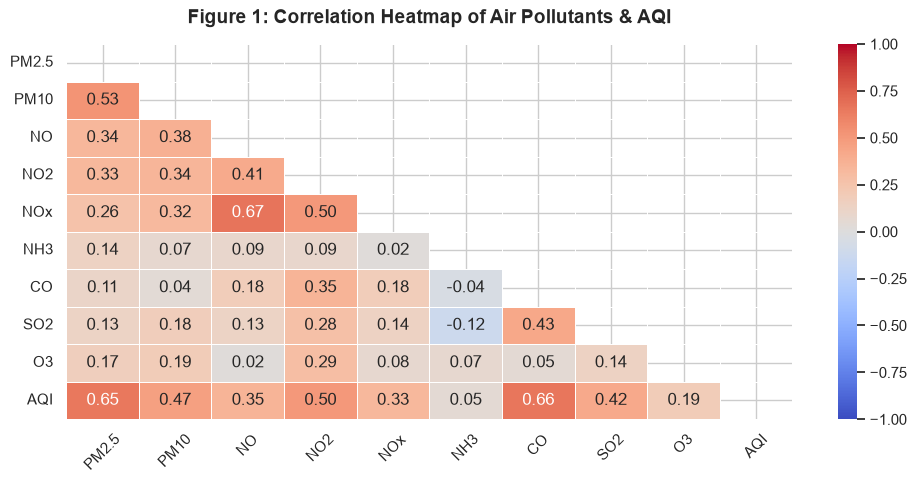

In [91]:
import seaborn as sns
plt.figure(figsize=(10, 5))
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
corr_matrix = df[pollutant_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Figure 1: Correlation Heatmap of Air Pollutants & AQI', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Top 10 Most Polluted Cities (Horizontal Bar Plot)
Type: Bar Plot

Purpose: Identifies the cities with the highest average AQI levels.

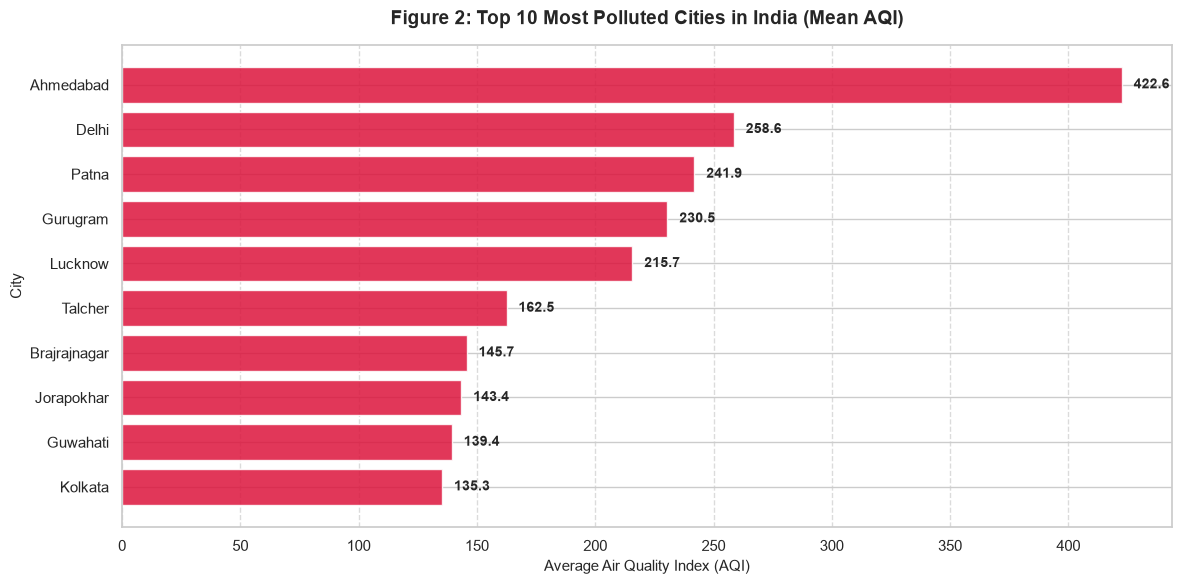

In [63]:
plt.figure(figsize=(12, 6))
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10).sort_values(ascending=True)

bars = plt.barh(top_cities.index, top_cities.values, color='crimson', alpha=0.85)
plt.title('Figure 2: Top 10 Most Polluted Cities in India (Mean AQI)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Air Quality Index (AQI)', fontsize=11)
plt.ylabel('City', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{width:.1f}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Seasonal AQI Distribution (Box Plots using Subplots)
Type: Box Plots with Subplots

Purpose: Compares the spread and median levels of AQI and PM2.5 across Indian seasons.

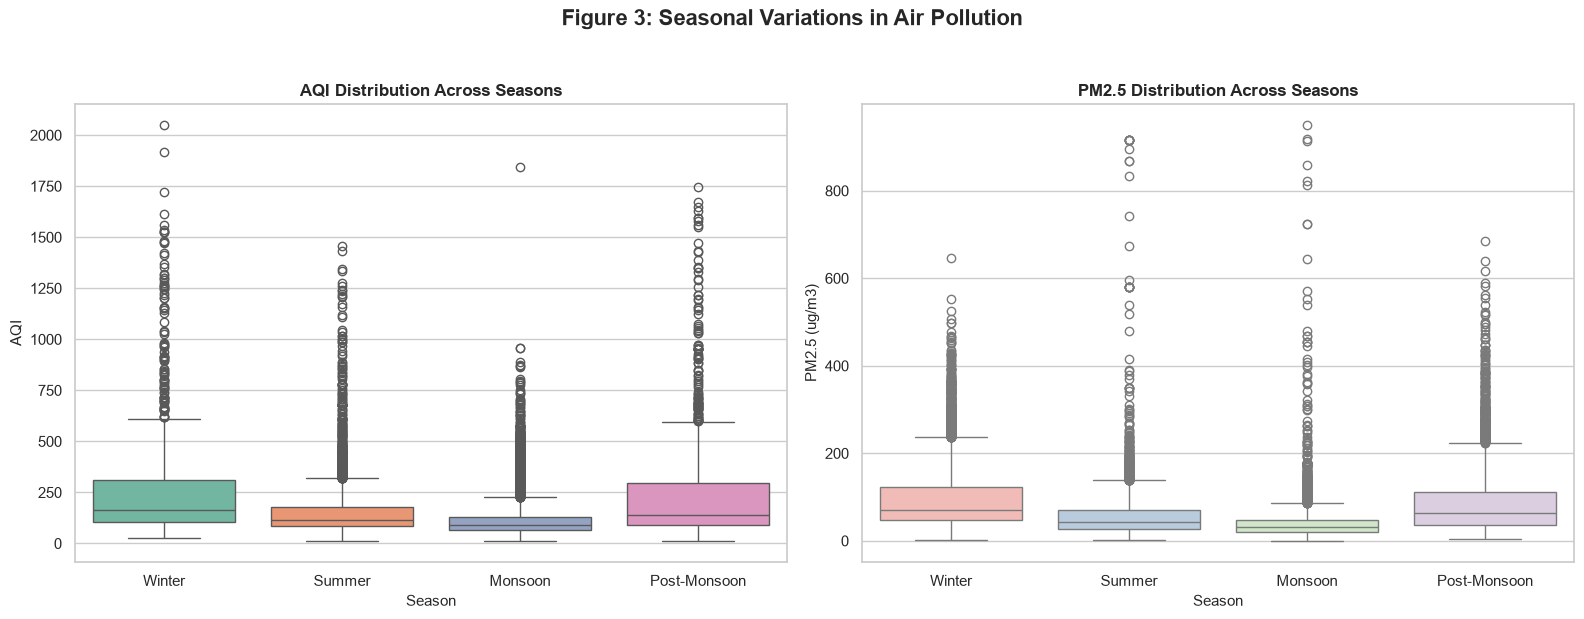

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df.dropna(subset=['AQI']), x='Season', y='AQI', ax=axes[0], palette='Set2', order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
axes[0].set_title('AQI Distribution Across Seasons', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=11)
axes[0].set_ylabel('AQI', fontsize=11)

sns.boxplot(data=df.dropna(subset=['PM2.5']), x='Season', y='PM2.5', ax=axes[1], palette='Pastel1', order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
axes[1].set_title('PM2.5 Distribution Across Seasons', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=11)
axes[1].set_ylabel('PM2.5 (ug/m3)', fontsize=11)

plt.suptitle('Figure 3: Seasonal Variations in Air Pollution', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4. AQI Health Bucket Proportions (Donut Chart)
Type: Pie / Donut Chart

Purpose: Shows the percentage breakdown of days falling into various health categories (Good, Moderate, Severe, etc.).

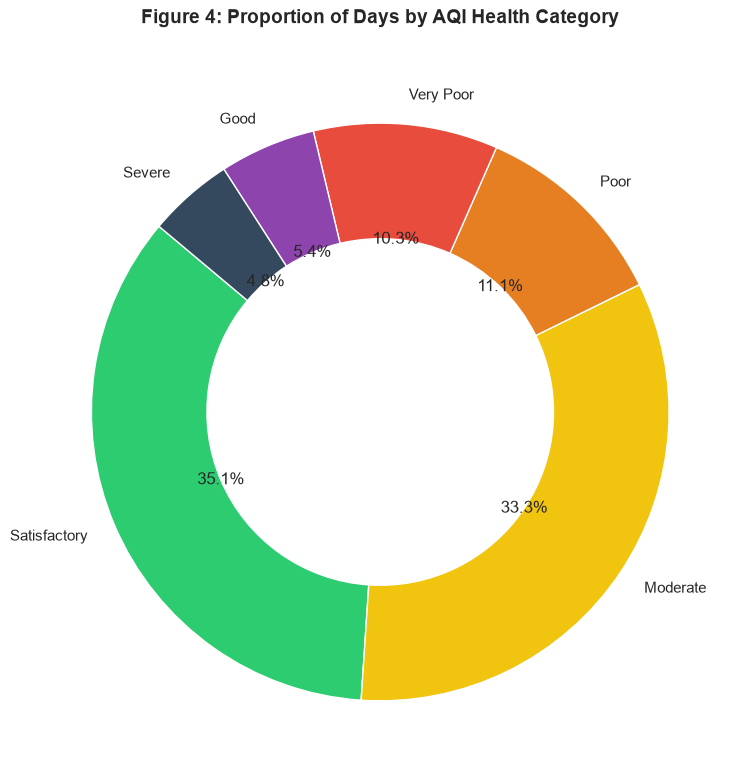

In [90]:
plt.figure(figsize=(8, 8))
bucket_counts = df['AQI_Bucket_Calculated'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad', '#34495e']

plt.pie(bucket_counts, labels=bucket_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Figure 4: Proportion of Days by AQI Health Category', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 5. PM2.5 vs PM10 Relationship (Scatter Plot with Regression)
Type: Scatter Plot

Purpose: Explores the correlation and linear trend between fine particulate matter (PM2.5) and coarse particulate matter (PM10).

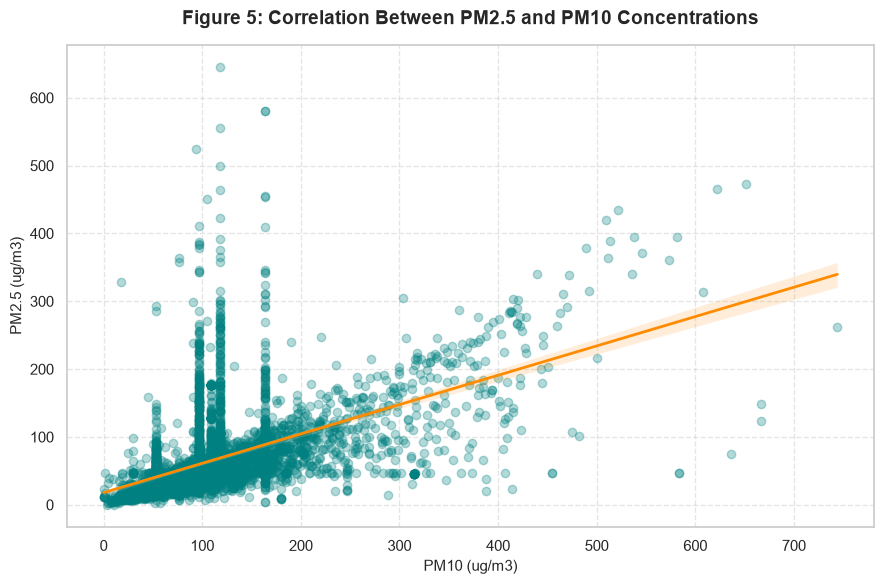

In [87]:
plt.figure(figsize=(9, 6))
sample_df = df.dropna(subset=['PM2.5', 'PM10']).sample(n=min(5000, len(df)), random_state=42)

sns.regplot(data=sample_df, x='PM10', y='PM2.5', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'darkorange', 'linewidth':2})
plt.title('Figure 5: Correlation Between PM2.5 and PM10 Concentrations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('PM10 (ug/m3)', fontsize=11)
plt.ylabel('PM2.5 (ug/m3)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6. Multi-Year Trend of Average AQI (Line Chart)
Type: Line Chart

Purpose: Tracks the yearly progression of overall air quality across major monitored cities.

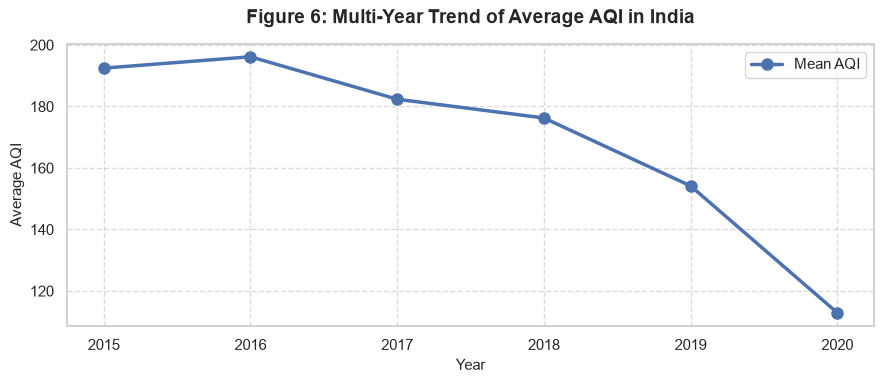

In [84]:
plt.figure(figsize=(9, 4))
yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o', color='b', linewidth=2.5, markersize=8, label='Mean AQI')
plt.title('Figure 6: Multi-Year Trend of Average AQI in India', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Average AQI', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_aqi['Year'])
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 7. Distribution Frequency of AQI Values (Histogram with KDE)
Type: Histogram & Density Plot

Purpose: Illustrates the statistical distribution skewness and frequency of AQI values.

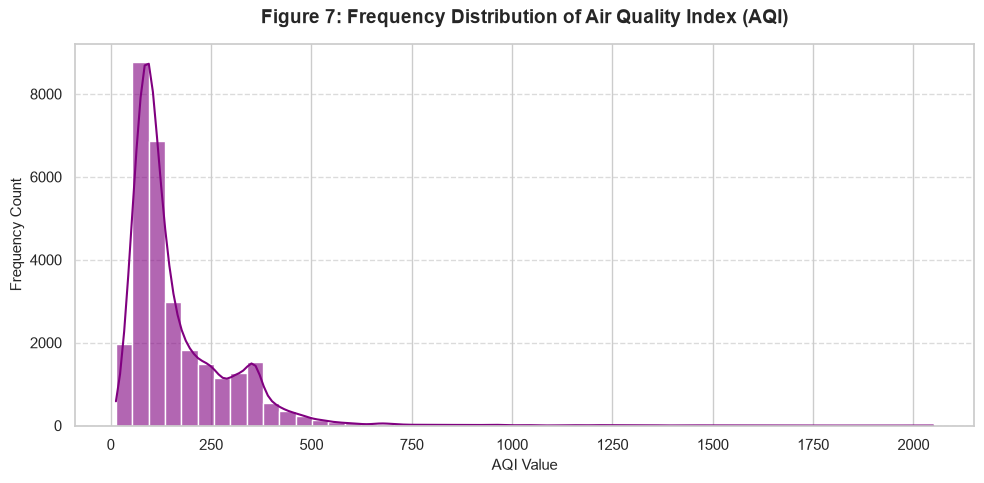

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(df['AQI'].dropna(), bins=50, kde=True, color='purple', alpha=0.6)
plt.title('Figure 7: Frequency Distribution of Air Quality Index (AQI)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('AQI Value', fontsize=11)
plt.ylabel('Frequency Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 8. Monthly Average Pollutant Levels (Multi-line Subplots)
Type: Subplot Line Charts

Purpose: Compares seasonal peaks across specific gaseous pollutants (NO2, SO2, O3, CO).

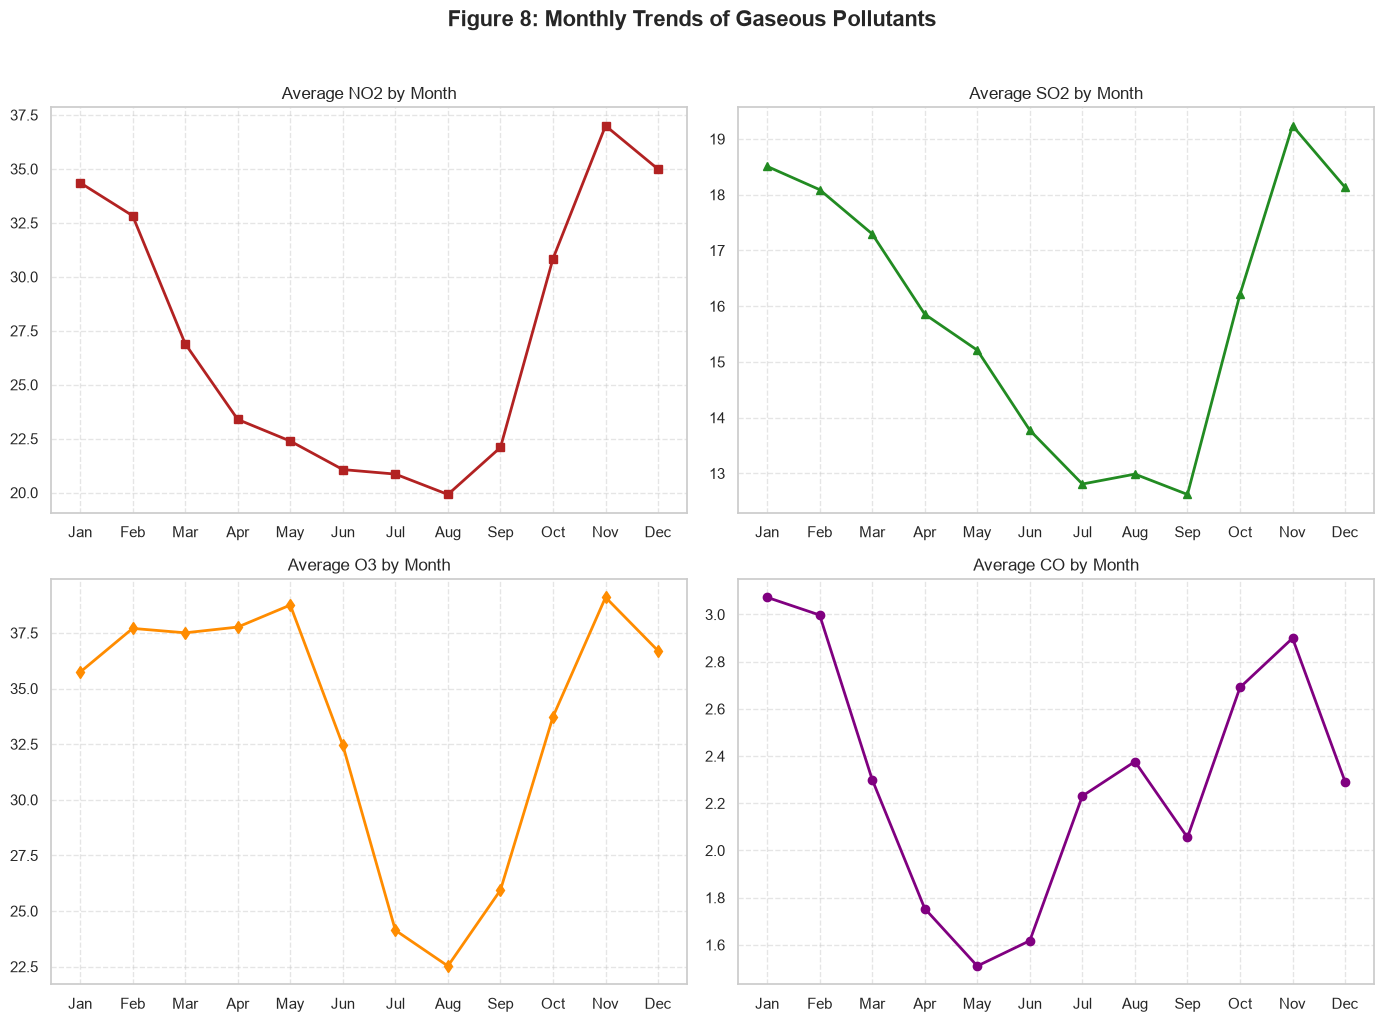

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
monthly_pollutants = df.groupby('Month')[['NO2', 'SO2', 'O3', 'CO']].mean().reset_index()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# NO2
axes[0, 0].plot(monthly_pollutants['Month'], monthly_pollutants['NO2'], marker='s', color='firebrick', linewidth=2)
axes[0, 0].set_title('Average NO2 by Month')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# SO2
axes[0, 1].plot(monthly_pollutants['Month'], monthly_pollutants['SO2'], marker='^', color='forestgreen', linewidth=2)
axes[0, 1].set_title('Average SO2 by Month')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# O3
axes[1, 0].plot(monthly_pollutants['Month'], monthly_pollutants['O3'], marker='d', color='darkorange', linewidth=2)
axes[1, 0].set_title('Average O3 by Month')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(months)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# CO
axes[1, 1].plot(monthly_pollutants['Month'], monthly_pollutants['CO'], marker='o', color='purple', linewidth=2)
axes[1, 1].set_title('Average CO by Month')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(months)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Figure 8: Monthly Trends of Gaseous Pollutants', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9. Multivariate Scatter Plot: CO vs NO2 Colored by Season
Type: Multivariate Scatter Plot

Purpose: Visualizes how carbon monoxide and nitrogen dioxide interact across different seasons.

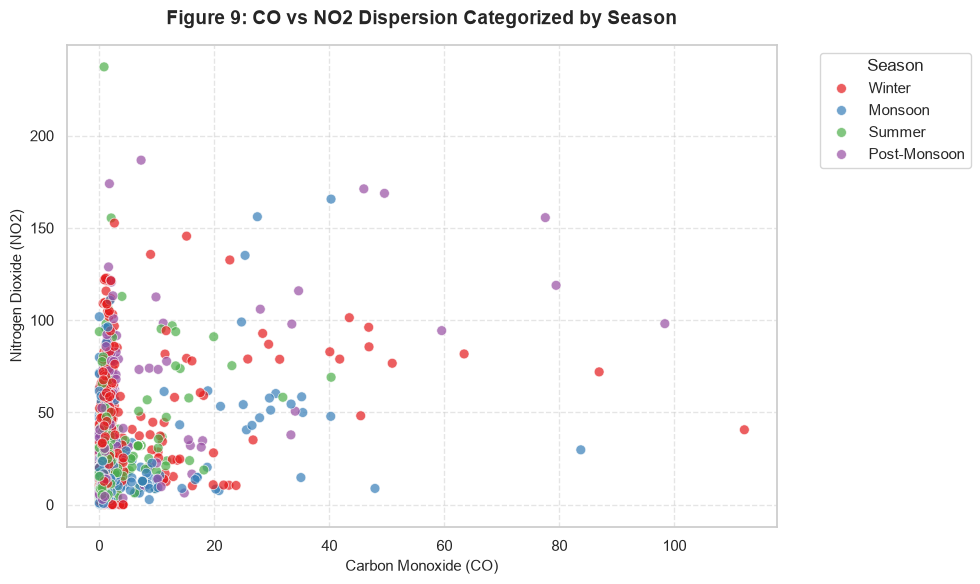

In [74]:
plt.figure(figsize=(10, 6))
sample_df = df.dropna(subset=['CO', 'NO2', 'Season']).sample(n=min(3000, len(df)), random_state=42)

sns.scatterplot(data=sample_df, x='CO', y='NO2', hue='Season', palette='Set1', alpha=0.7, s=50)
plt.title('Figure 9: CO vs NO2 Dispersion Categorized by Season', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Carbon Monoxide (CO)', fontsize=11)
plt.ylabel('Nitrogen Dioxide (NO2)', fontsize=11)
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10. Top Cleanest vs Most Polluted Cities (Grouped Comparison Bar Chart)
Type: Vertical Bar Plot

Purpose: Highlights the contrast between the cleanest cities and the most polluted cities based on mean PM2.5 levels.

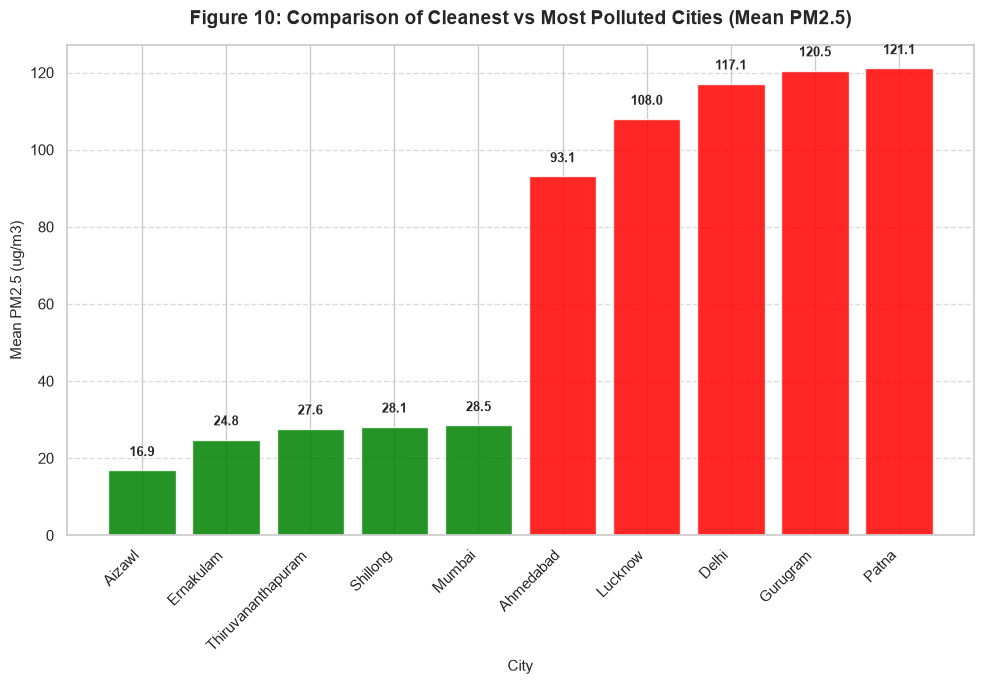

In [81]:
plt.figure(figsize=(10, 7))
city_pm25 = df.groupby('City')['PM2.5'].mean().sort_values()
top_clean = city_pm25.head(5)
top_polluted = city_pm25.tail(5)
extreme_cities = pd.concat([top_clean, top_polluted])

colors = ['green']*5 + ['red']*5
bars = plt.bar(range(len(extreme_cities)), extreme_cities.values, color=colors, alpha=0.85)

plt.title('Figure 10: Comparison of Cleanest vs Most Polluted Cities (Mean PM2.5)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=11)
plt.ylabel('Mean PM2.5 (ug/m3)', fontsize=11)
plt.xticks(range(len(extreme_cities)), extreme_cities.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3, f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Air Quality Analysis: Summary & Findings
---

### Major Takeaways

* **Dataset Scale & Scope:** The analysis examined 29,531 daily air quality records spanning multiple metropolitan cities across India from 2015 to 2020.
* **General Air Condition Distribution:** The majority of recorded days fell into the "Satisfactory" (35.06%) and "Moderate" (33.32%) air quality categories, though severe pollution events occurred regularly.
* **Primary Pollutant Drivers:** Particulate matter (specifically PM2.5 and PM10) along with Carbon Monoxide (CO) serve as the strongest linear drivers of dangerous spikes in overall Air Quality Index (AQI) values.

---

### Key Insights

* **Severe Urban Disparities:** Ahmedabad recorded the highest average AQI levels (approx. 422.6), closely followed by other heavily impacted metropolitan centers such as Delhi, Patna, Gurugram, and Lucknow.
* **Pronounced Seasonal Cycles:** Winter and post-monsoon periods suffer from the worst pollution levels (averaging over AQI 205–213), whereas monsoon seasons provide the most effective natural cleansing relief (dropping average AQI down to 121.28).
* **Consistent Weekly Trends:** Pollution levels remain remarkably uniform across all days of the week, indicating that standard weekday traffic and weekend activities have a comparable overarching effect on city-wide air quality.
* **Data Integrity & Imputation:** Initial exploratory data checks revealed significant missing data rates in parameters like Xylene (61.32%) and PM10 (37.72%), requiring robust group-wise cleaning and standard CPCB classification mapping.

---

### Overall Conclusion

The air quality data demonstrates that urban pollution in India is heavily dictated by geographic hotspots and seasonal patterns. While baseline air conditions often hover within moderate or satisfactory brackets, extreme particulate and gas spikes during winter months, particularly in high-risk cities like Ahmedabad and Delhi; pose significant environmental and public health challenges.